In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="talk")

In [2]:
# ========= Paths =========

DATA_DIR = Path("../../results/processed_hrv")

INPUT_FILE = DATA_DIR / "basal_v2_clean.csv"

FIG_DIR = Path("../../results/eda_figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = Path("../../results/eda_tables")
TABLE_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
df = pd.read_csv(INPUT_FILE)

print(df.shape)
df.head()

(530, 26)


,sex,age,weight_kg,height_cm_final,height_m_final,imc_final,bp_systolic,bp_diastolic,bp_pam,bp_pp,...,t2m_pre_hf,t2m_pre_lf,t2m_pre_vlf,mean_hr_from_rr,height_inconsistent,imc_inconsistent,hr_rr_inconsistent,n_integrity_flags,n_range_flags,n_total_qc_flags
0,1,75,70.0,160.0,1.60,27.343750,108,70,82.666667,38,...,222,713,172,80.213904,False,False,False,0,0,0
1,1,66,52.0,149.0,1.49,23.422368,122,72,88.666667,50,...,87,226,29,62.959077,False,False,False,0,0,0
2,2,77,81.0,170.0,1.70,28.027682,125,85,98.333333,40,...,26,137,9,68.415051,False,False,False,0,0,0
3,1,77,85.0,160.0,1.60,33.203125,126,72,90.000000,54,...,118,130,14,73.260073,False,False,False,0,0,0
4,1,73,69.0,151.0,1.51,30.261831,130,80,96.666667,50,...,66,66,18,70.921986,False,False,False,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 530 entries, 0 to 529
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sex                  530 non-null    int64  
 1   age                  530 non-null    int64  
 2   weight_kg            530 non-null    float64
 3   height_cm_final      530 non-null    float64
 4   height_m_final       530 non-null    float64
 5   imc_final            530 non-null    float64
 6   bp_systolic          530 non-null    int64  
 7   bp_diastolic         530 non-null    int64  
 8   bp_pam               530 non-null    float64
 9   bp_pp                530 non-null    int64  
 10  bp_pp_recomputed     530 non-null    int64  
 11  bp_pam_recomputed    530 non-null    float64
 12  t2m_pre_mean_rr      530 non-null    float64
 13  t2m_pre_mean_hr      529 non-null    float64
 14  t2m_pre_sdnn         519 non-null    float64
 15  t2m_pre_rmssd        522 non-null    flo

In [5]:
hrv_cols = [
    "t2m_pre_mean_rr",
    "t2m_pre_mean_hr",
    "t2m_pre_sdnn",
    "t2m_pre_rmssd",
    "t2m_pre_hf",
    "t2m_pre_lf",
    "t2m_pre_vlf",
]

phys_cols = [
    "sex",
    "age",
    "weight_kg",
    "height_cm_final",
    "height_m_final",
    "imc_final",
    "bp_systolic",
    "bp_diastolic",
    "bp_pam",
    "bp_pp",
]

qc_cols = [
    "height_inconsistent",
    "imc_inconsistent",
    "hr_rr_inconsistent",
    "n_total_qc_flags",
]

analysis_cols = hrv_cols + phys_cols + qc_cols
analysis_cols = [c for c in analysis_cols if c in df.columns]

analysis_cols

['t2m_pre_mean_rr',
 't2m_pre_mean_hr',
 't2m_pre_sdnn',
 't2m_pre_rmssd',
 't2m_pre_hf',
 't2m_pre_lf',
 't2m_pre_vlf',
 'sex',
 'age',
 'weight_kg',
 'height_cm_final',
 'height_m_final',
 'imc_final',
 'bp_systolic',
 'bp_diastolic',
 'bp_pam',
 'bp_pp',
 'height_inconsistent',
 'imc_inconsistent',
 'hr_rr_inconsistent',
 'n_total_qc_flags']

In [6]:
missing_table = pd.DataFrame({
    "missing_n": df[analysis_cols].isna().sum(),
    "missing_pct": (df[analysis_cols].isna().mean() * 100).round(2)
}).sort_values("missing_n", ascending=False)

missing_table

,missing_n,missing_pct
t2m_pre_sdnn,11,2.08
t2m_pre_rmssd,8,1.51
t2m_pre_mean_hr,1,0.19
t2m_pre_mean_rr,0,0.00
t2m_pre_hf,0,0.00
t2m_pre_lf,0,0.00
t2m_pre_vlf,0,0.00
sex,0,0.00
age,0,0.00
weight_kg,0,0.00


In [7]:
missing_table.to_csv(TABLE_DIR / "missing_table.csv")

In [8]:
desc = df[analysis_cols].describe().T
desc

,count,mean,std,min,25%,50%,75%,max
t2m_pre_mean_rr,530.0,843.227925,160.393377,68.000000,768.000000,850.500000,944.50000,1296.000000
t2m_pre_mean_hr,529.0,71.338374,11.376680,10.000000,63.000000,70.000000,77.00000,128.000000
t2m_pre_sdnn,519.0,135.923121,95.356937,4.800000,61.000000,140.000000,197.00000,626.000000
t2m_pre_rmssd,522.0,14.974521,8.895968,0.500000,9.950000,13.700000,18.17500,71.600000
t2m_pre_hf,530.0,429.788679,1209.828365,1.000000,36.250000,98.000000,276.25000,13160.000000
t2m_pre_lf,530.0,452.969811,1158.634908,7.000000,55.250000,116.000000,270.00000,10220.000000
t2m_pre_vlf,530.0,115.300000,264.794157,1.000000,15.000000,31.000000,82.75000,2340.000000
sex,530.0,1.309434,0.462697,1.000000,1.000000,1.000000,2.00000,2.000000
age,530.0,70.862264,6.247108,50.000000,66.000000,71.000000,75.00000,89.000000
weight_kg,530.0,75.039434,14.026612,47.000000,65.125000,72.950000,82.27500,120.000000


In [9]:
desc.to_csv(TABLE_DIR / "descriptive_stats.csv")

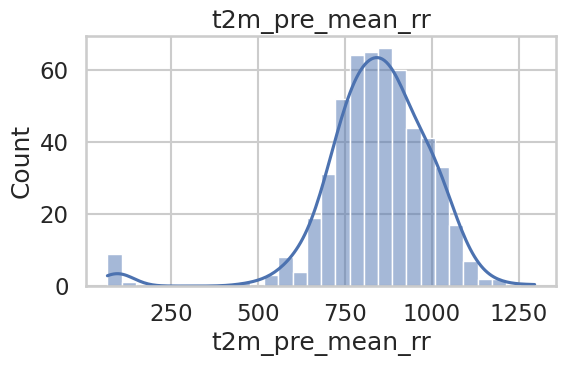

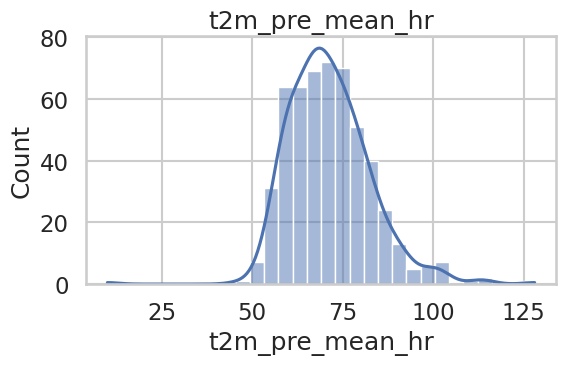

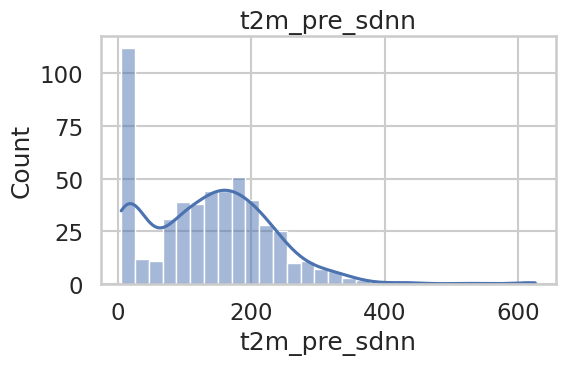

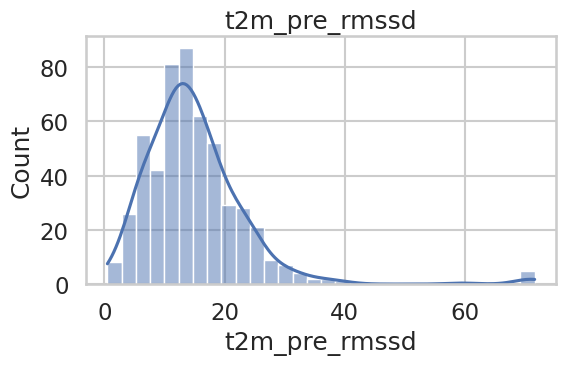

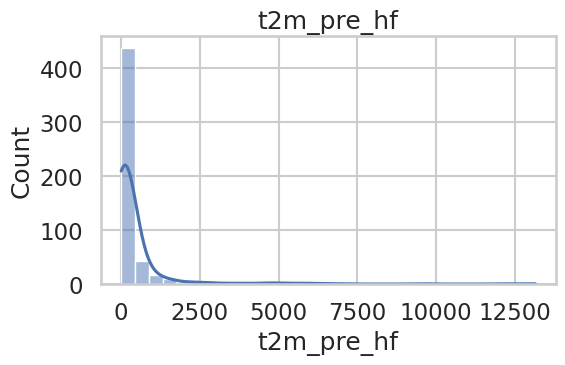

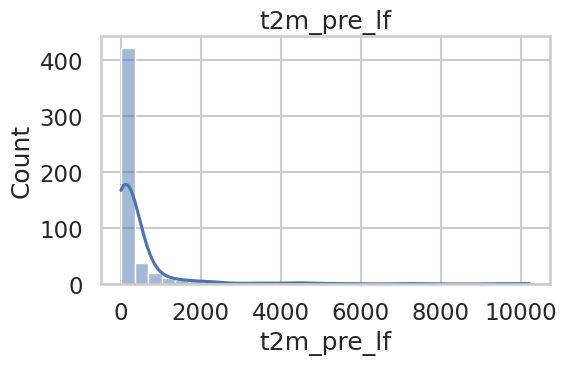

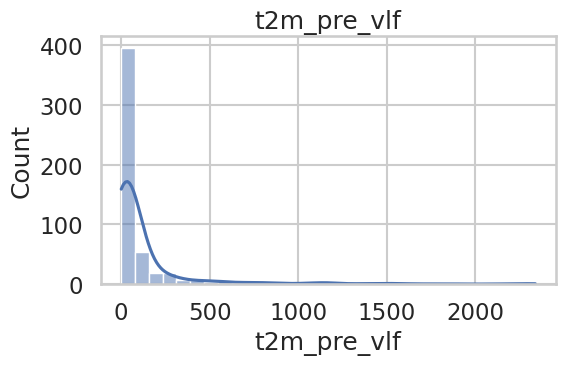

In [10]:
for col in hrv_cols:
    
    if col not in df.columns:
        continue
    
    plt.figure(figsize=(6,4))
    
    sns.histplot(
        df[col],
        bins=30,
        kde=True
    )
    
    plt.title(col)
    plt.tight_layout()
    
    plt.savefig(FIG_DIR / f"hist_{col}.png", dpi=300)
    plt.show()

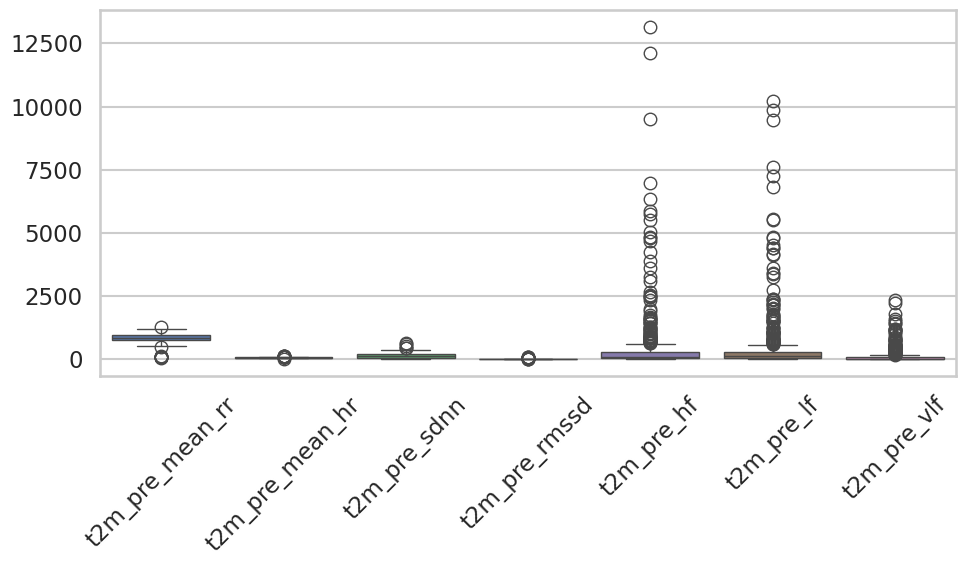

In [11]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df[hrv_cols]
)

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(FIG_DIR / "boxplot_hrv.png", dpi=300)

plt.show()

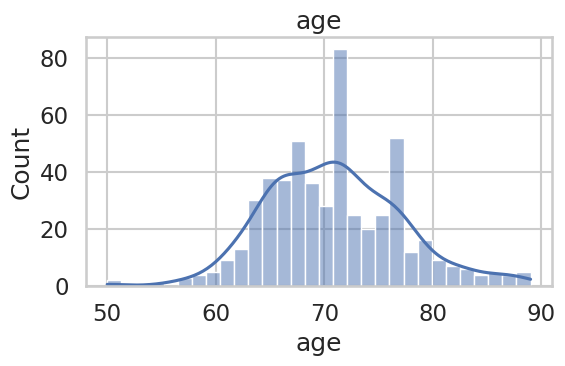

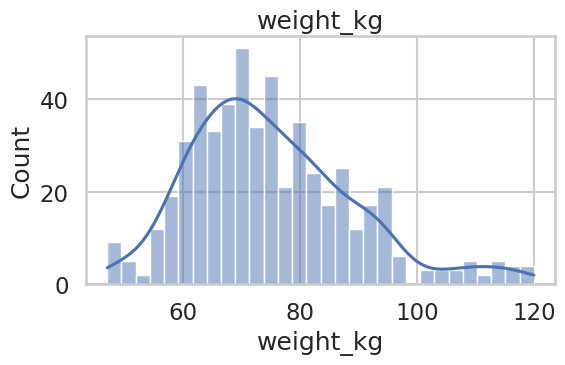

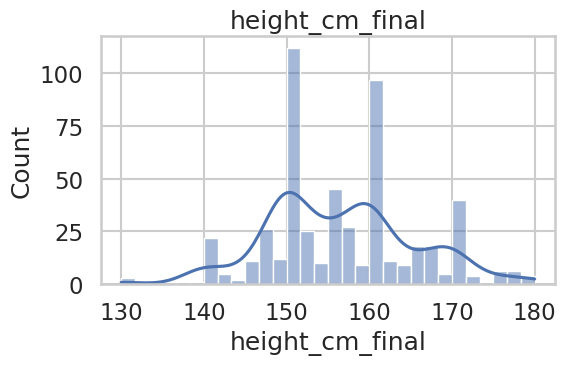

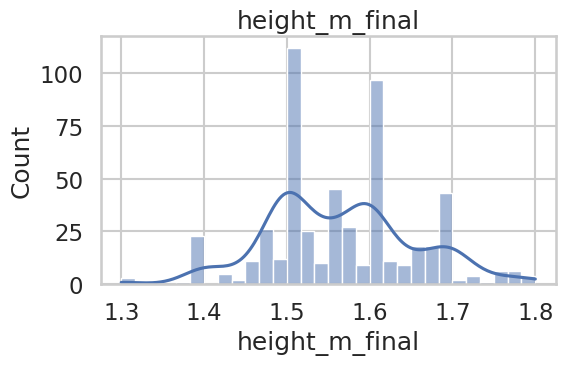

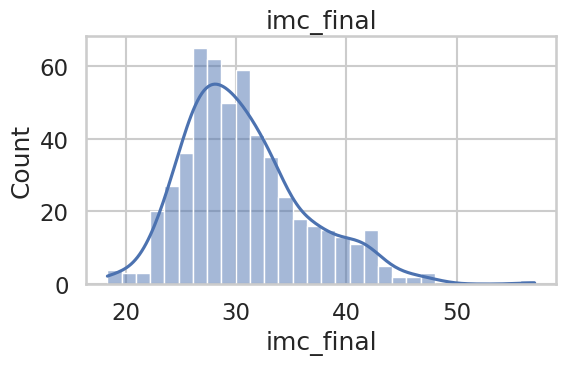

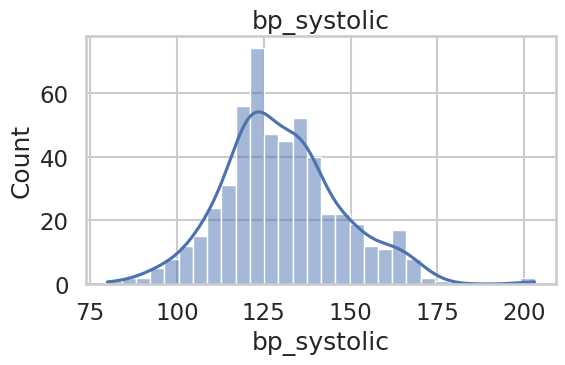

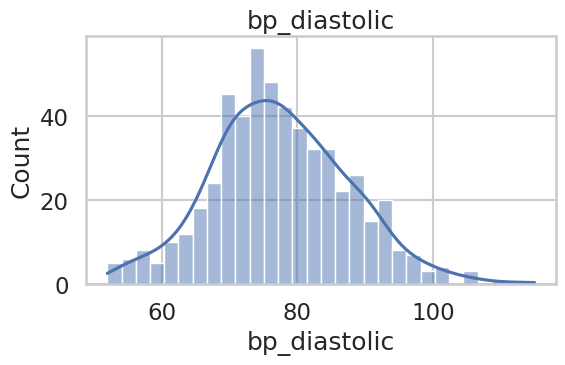

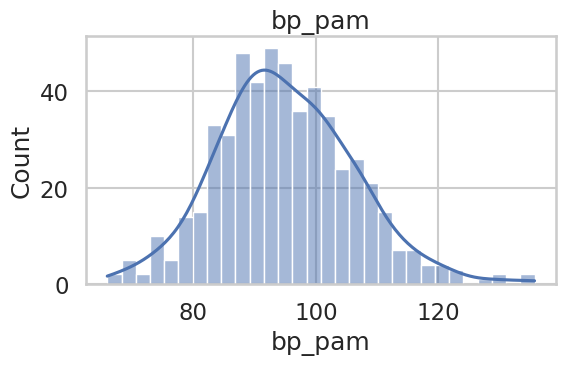

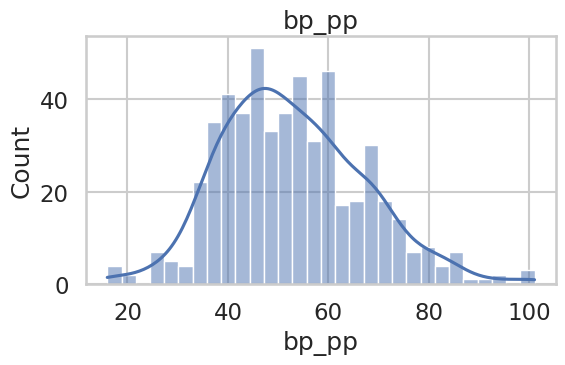

In [12]:
for col in phys_cols:
    
    if col not in df.columns:
        continue
    
    if col == "sex":
        continue
    
    plt.figure(figsize=(6,4))
    
    sns.histplot(
        df[col],
        bins=30,
        kde=True
    )
    
    plt.title(col)
    plt.tight_layout()
    
    plt.savefig(FIG_DIR / f"hist_{col}.png", dpi=300)
    plt.show()

In [13]:
df["sex"].value_counts()

sex
1    366
2    164
Name: count, dtype: int64

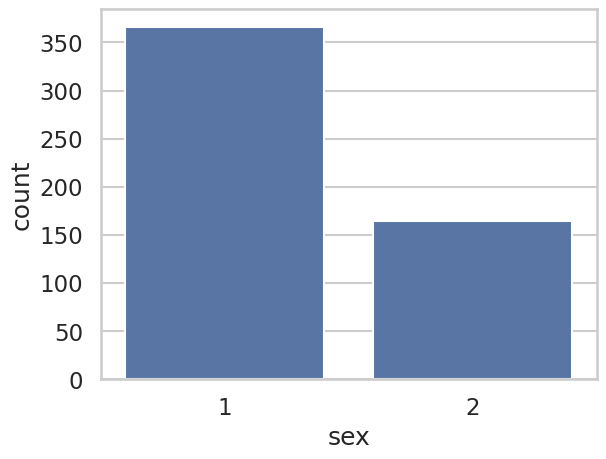

In [14]:
sns.countplot(
    x="sex",
    data=df
)

plt.savefig(FIG_DIR / "sex_counts.png", dpi=300)

plt.show()

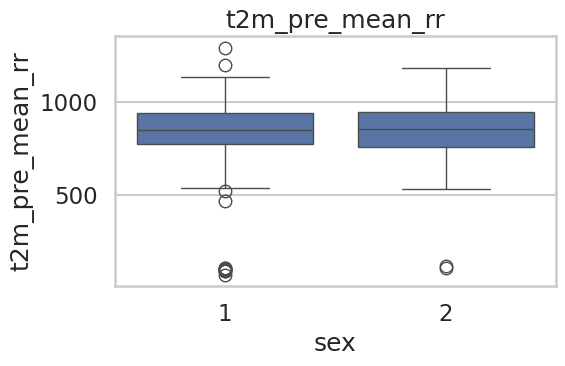

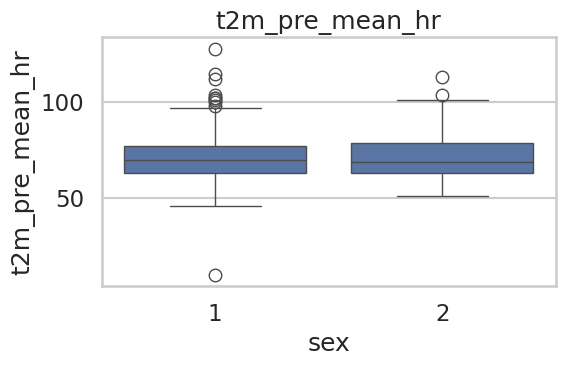

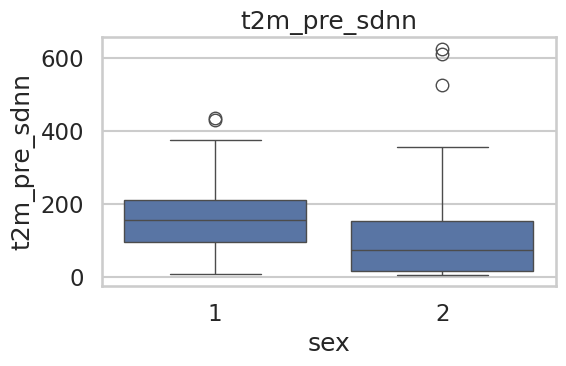

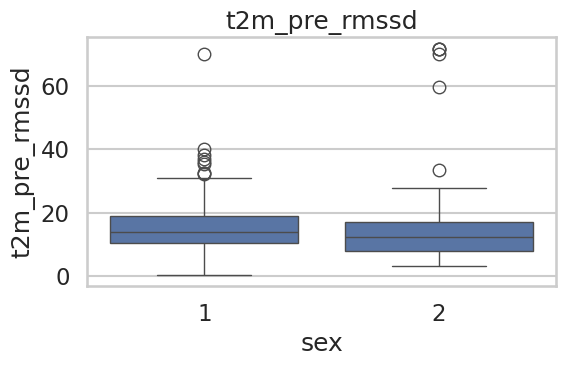

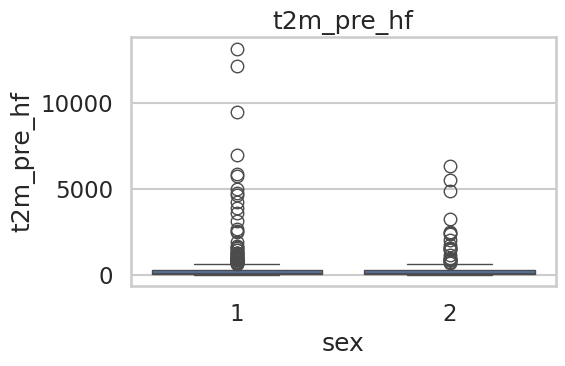

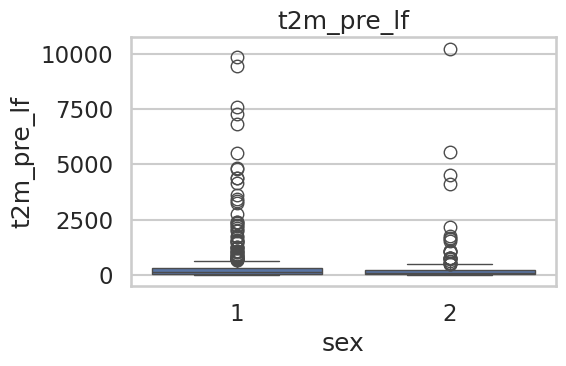

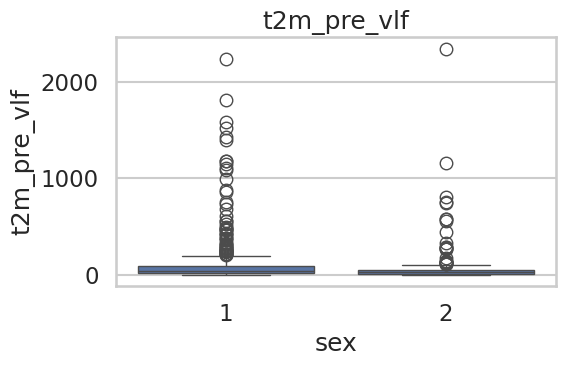

In [15]:
for col in hrv_cols:
    
    if col not in df.columns:
        continue
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(
        x="sex",
        y=col,
        data=df
    )
    
    plt.title(col)
    plt.tight_layout()
    
    plt.savefig(FIG_DIR / f"{col}_by_sex.png", dpi=300)
    plt.show()

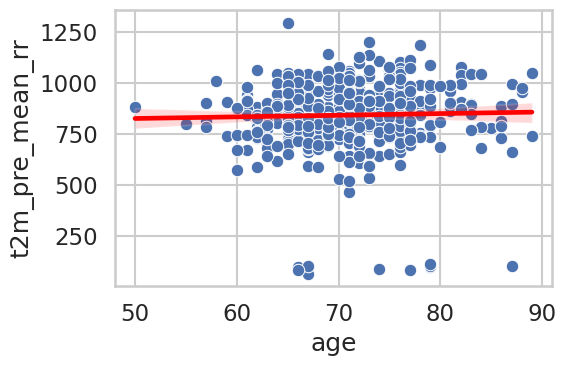

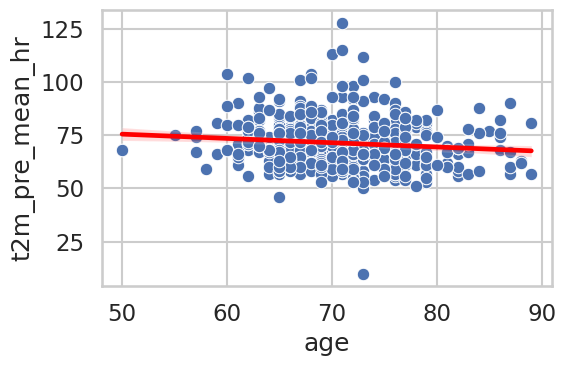

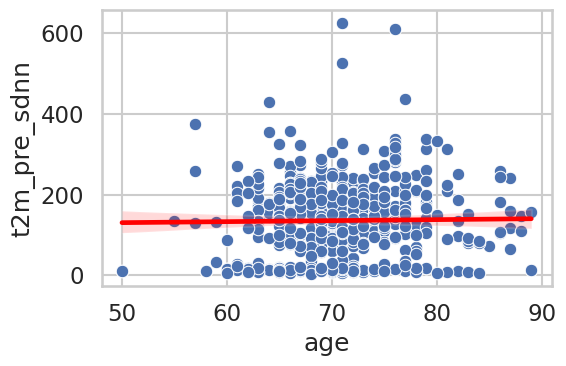

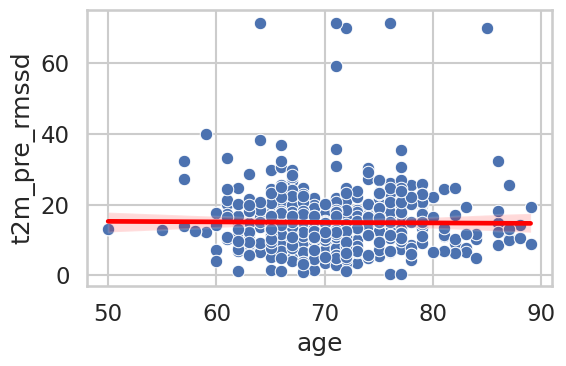

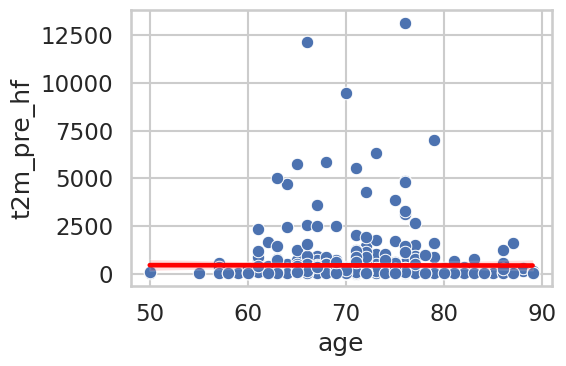

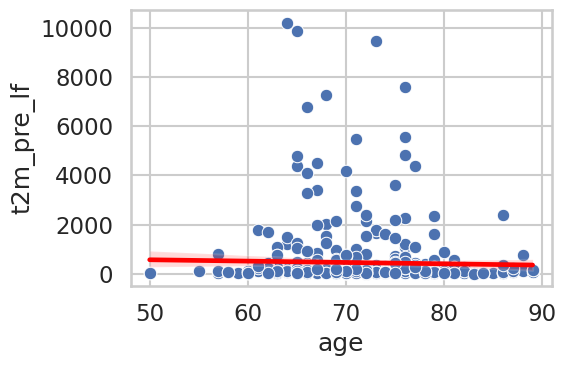

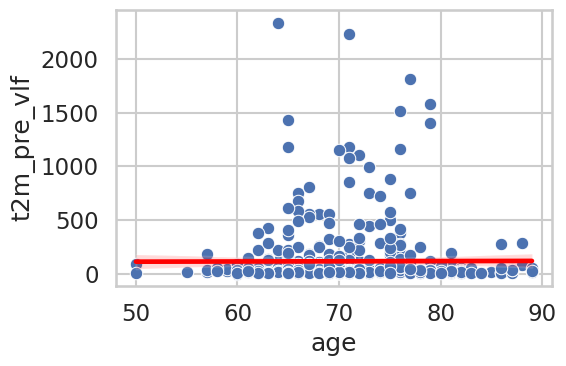

In [16]:
for col in hrv_cols:
    
    if col not in df.columns:
        continue
    
    plt.figure(figsize=(6,4))
    
    sns.scatterplot(
        x="age",
        y=col,
        data=df
    )
    
    sns.regplot(
        x="age",
        y=col,
        data=df,
        scatter=False,
        color="red"
    )
    
    plt.tight_layout()
    
    plt.savefig(FIG_DIR / f"{col}_vs_age.png", dpi=300)
    plt.show()

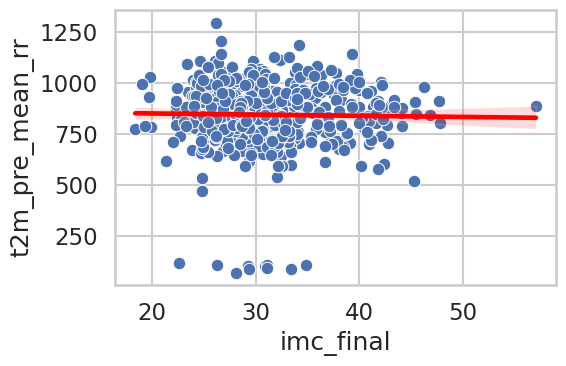

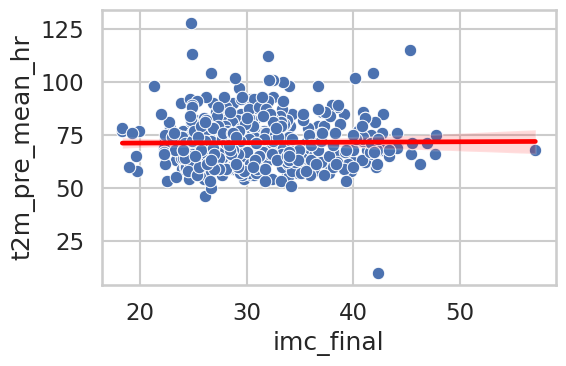

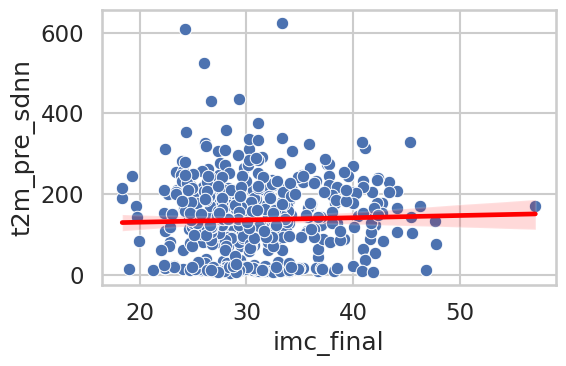

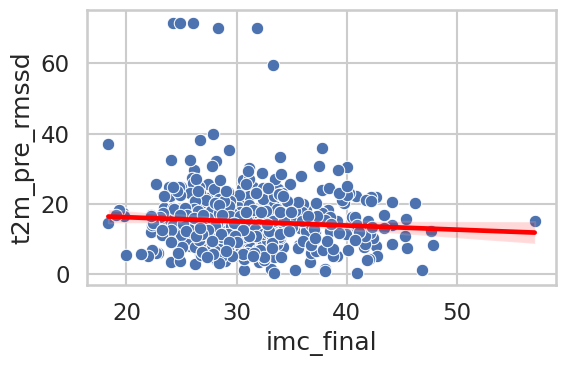

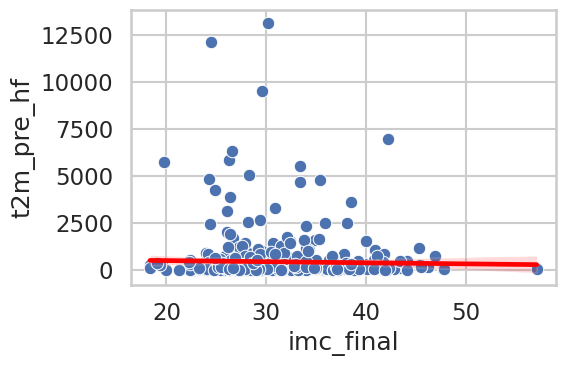

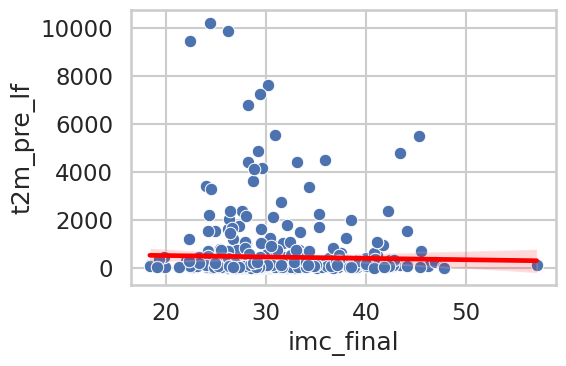

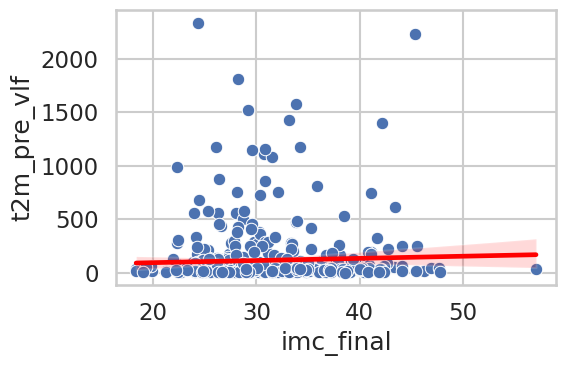

In [17]:
for col in hrv_cols:
    
    plt.figure(figsize=(6,4))
    
    sns.scatterplot(
        x="imc_final",
        y=col,
        data=df
    )
    
    sns.regplot(
        x="imc_final",
        y=col,
        data=df,
        scatter=False,
        color="red"
    )
    
    plt.tight_layout()
    
    plt.savefig(FIG_DIR / f"{col}_vs_bmi.png", dpi=300)
    plt.show()

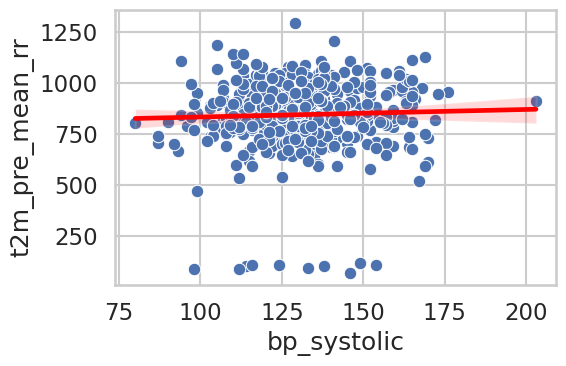

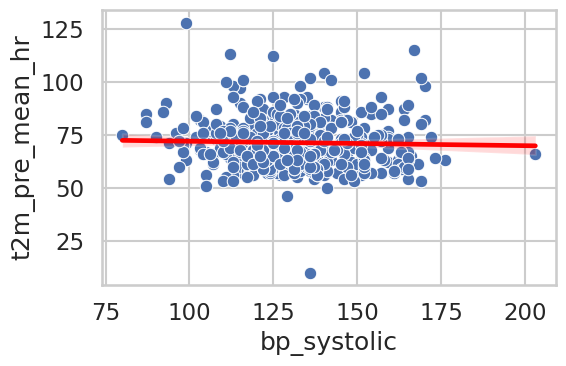

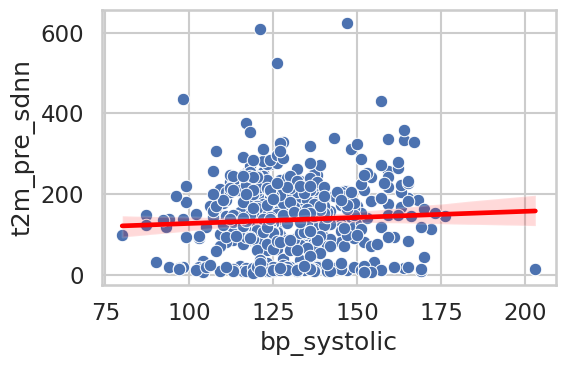

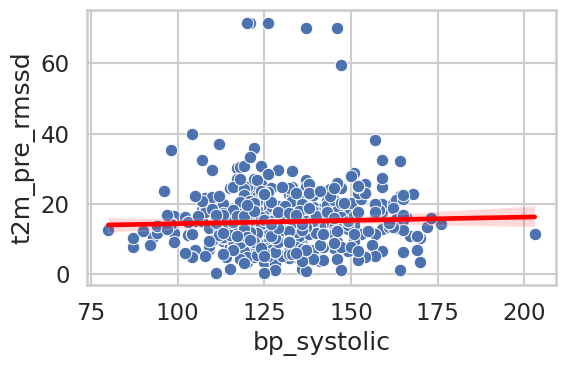

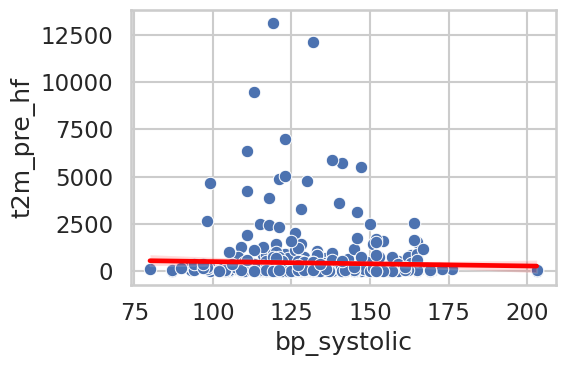

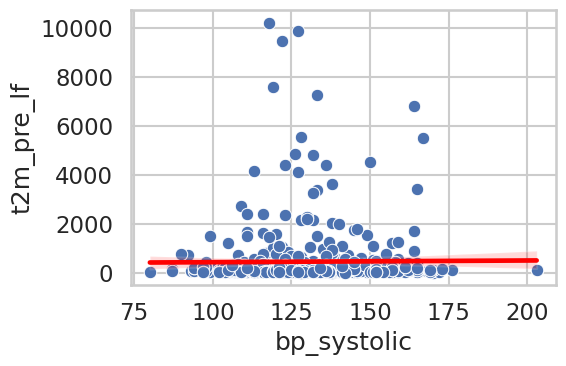

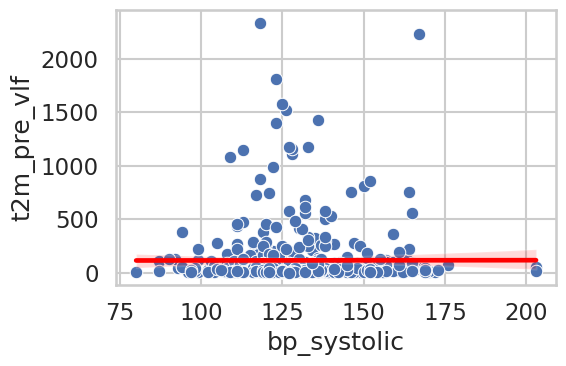

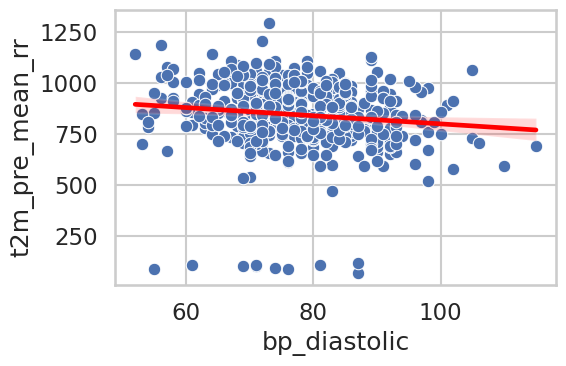

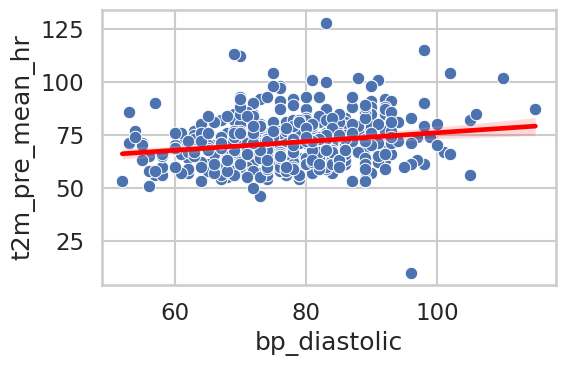

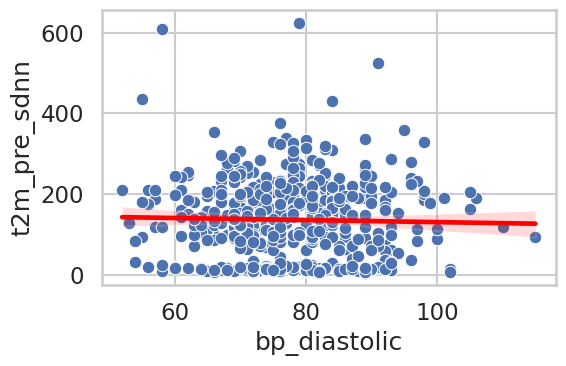

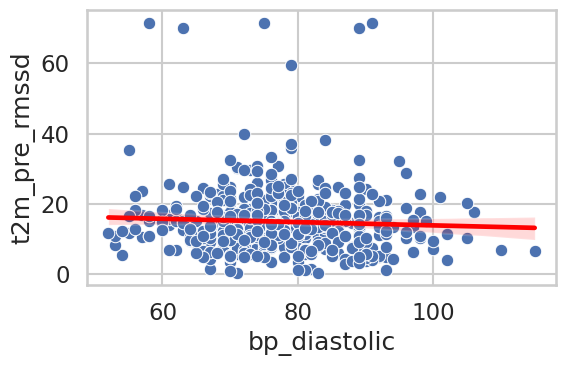

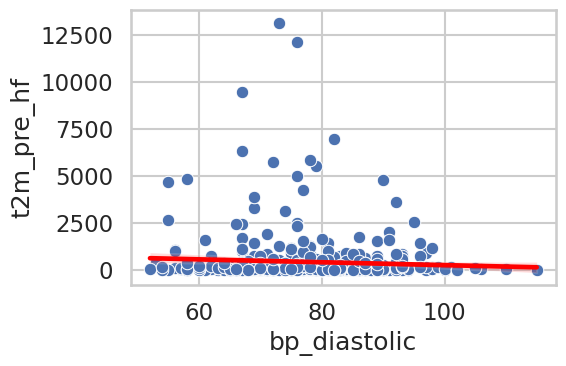

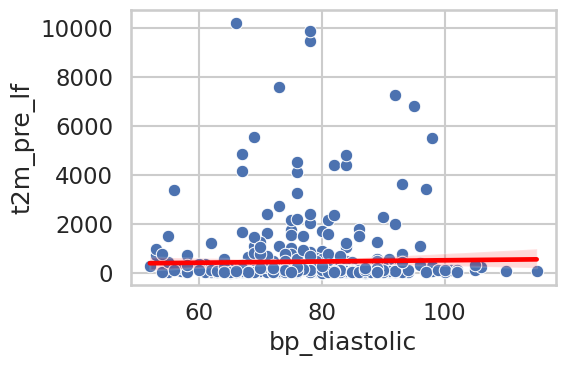

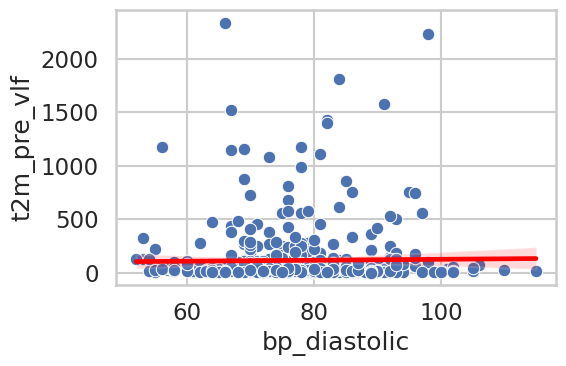

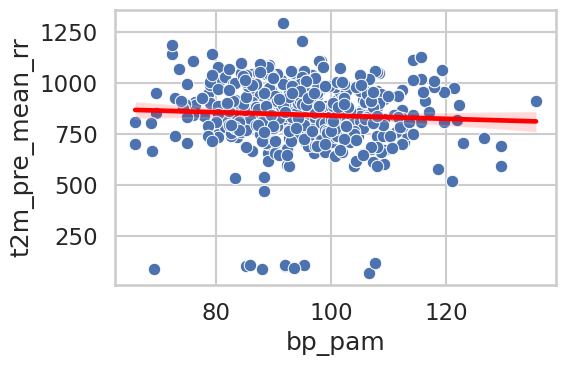

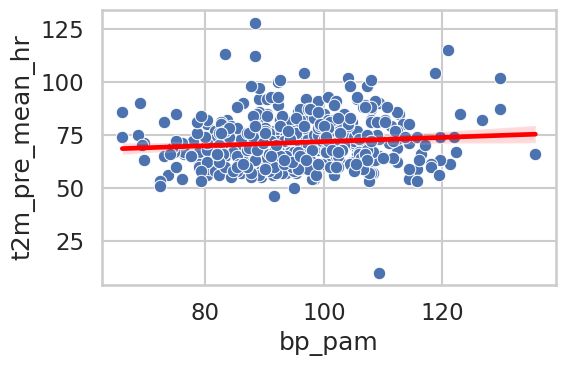

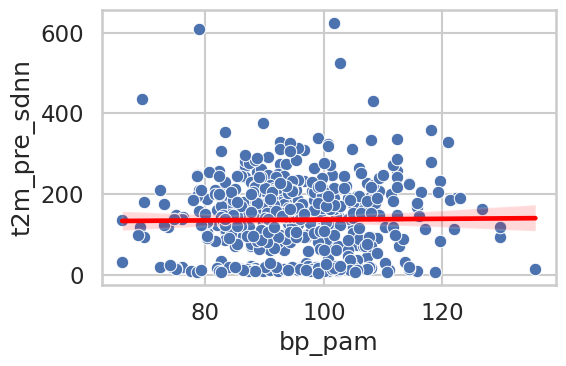

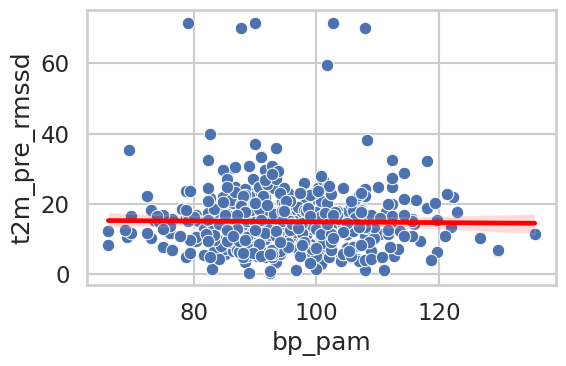

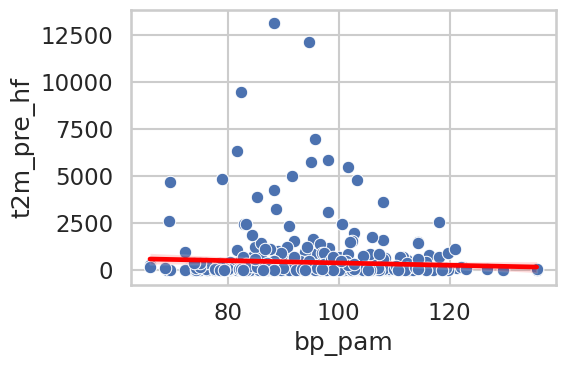

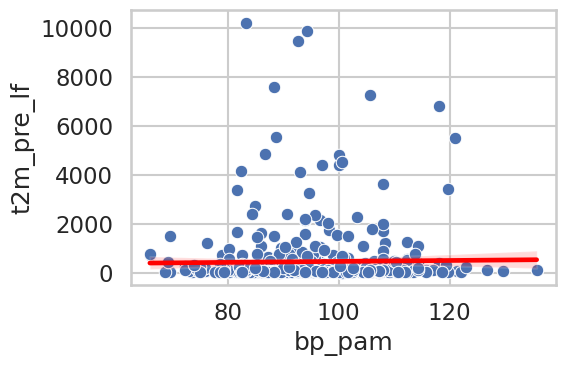

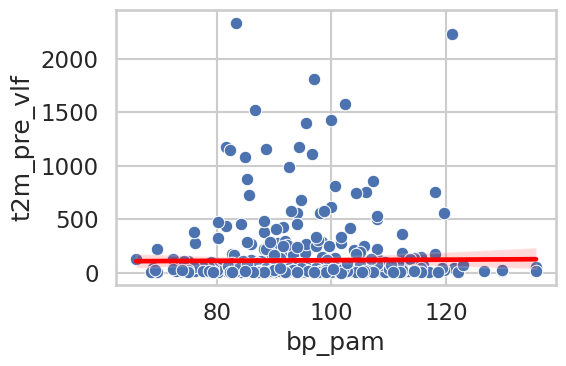

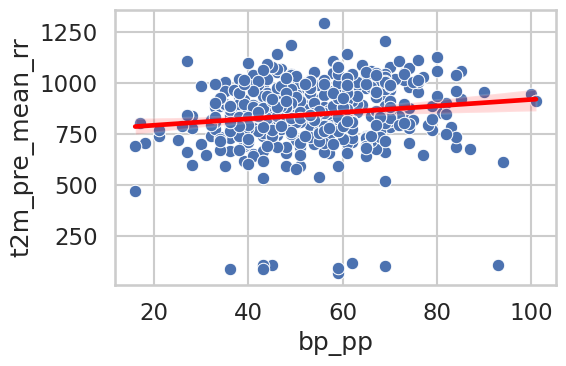

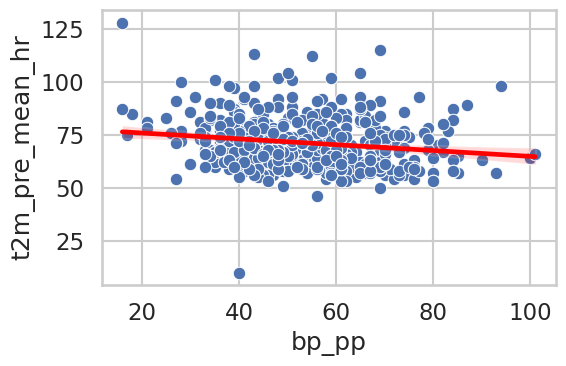

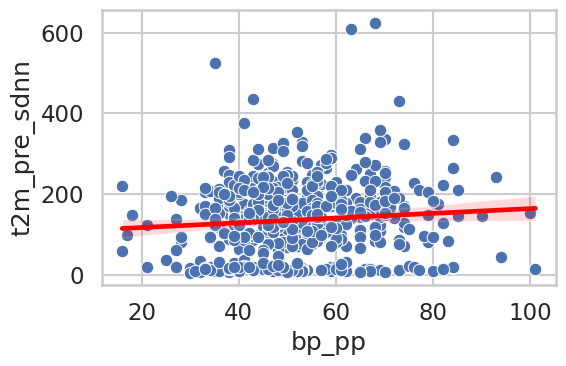

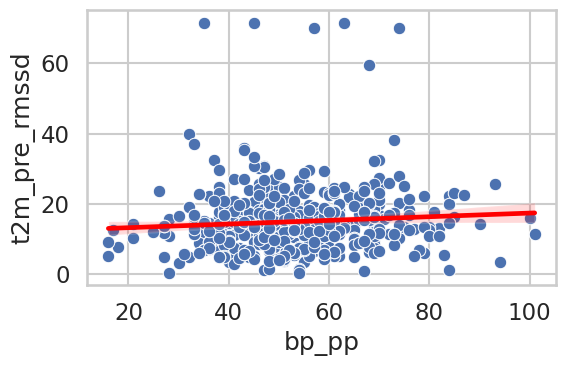

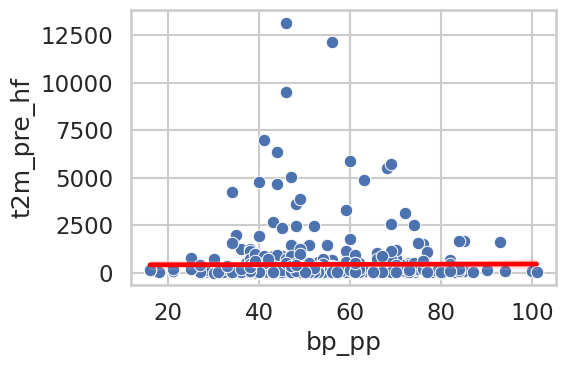

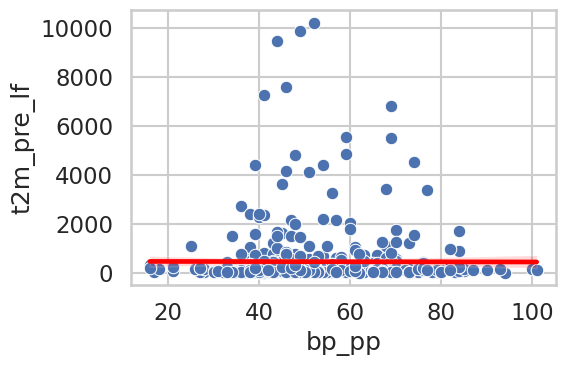

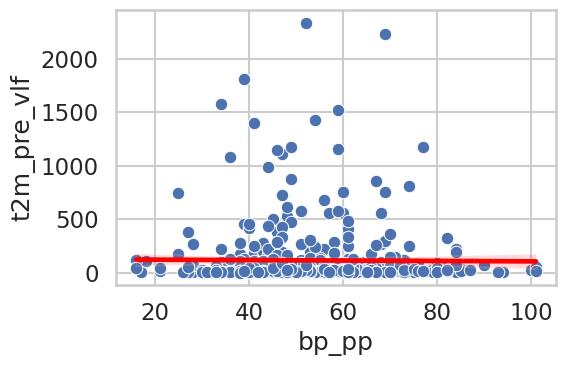

In [18]:
bp_vars = [
    "bp_systolic",
    "bp_diastolic",
    "bp_pam",
    "bp_pp",
]

for bp in bp_vars:
    
    for col in hrv_cols:
        
        plt.figure(figsize=(6,4))
        
        sns.scatterplot(
            x=bp,
            y=col,
            data=df
        )
        
        sns.regplot(
            x=bp,
            y=col,
            data=df,
            scatter=False,
            color="red"
        )
        
        plt.tight_layout()
        
        plt.savefig(FIG_DIR / f"{col}_vs_{bp}.png", dpi=300)
        plt.show()

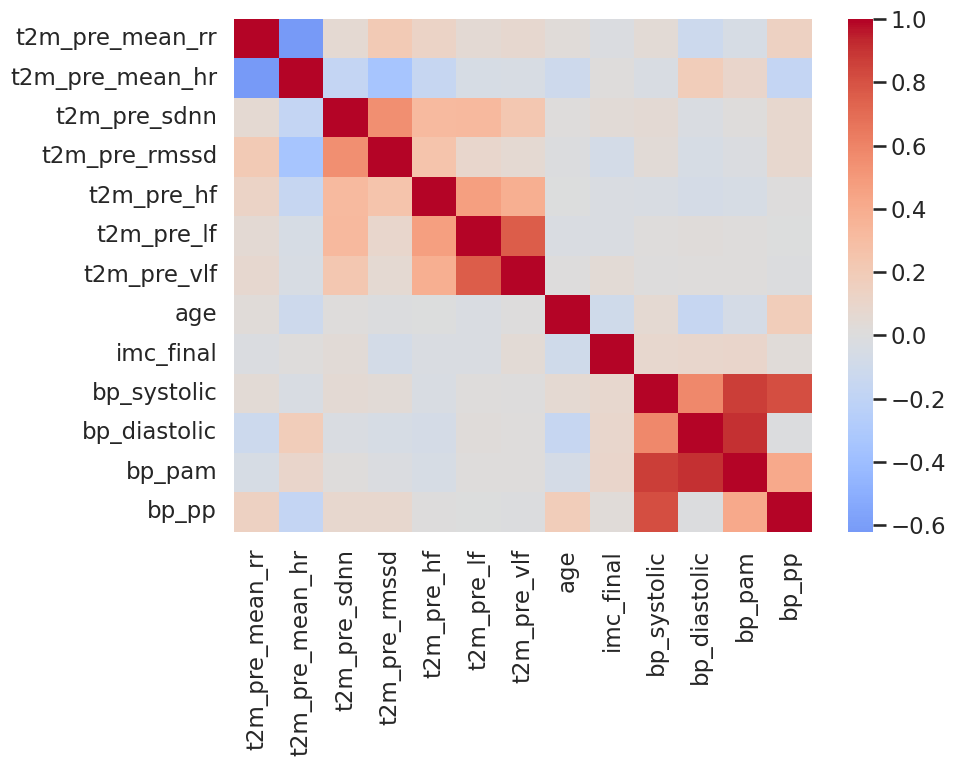

In [19]:
corr_cols = hrv_cols + [
    "age",
    "imc_final",
    "bp_systolic",
    "bp_diastolic",
    "bp_pam",
    "bp_pp",
]

corr_cols = [c for c in corr_cols if c in df.columns]

corr = df[corr_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.tight_layout()

plt.savefig(FIG_DIR / "correlation_matrix.png", dpi=300)

plt.show()

In [20]:
corr.to_csv(TABLE_DIR / "correlation_matrix.csv")

In [21]:
df["n_total_qc_flags"].value_counts()

n_total_qc_flags
0    503
2     19
1      8
Name: count, dtype: int64

In [22]:
df_clean = df[df["n_total_qc_flags"] == 0].copy()

print(df.shape)
print(df_clean.shape)

(530, 26)
(503, 26)


In [23]:
df_clean[analysis_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
t2m_pre_mean_rr,503.0,857.745527,123.044444,468.000000,777.500000,854.000000,944.000000,1296.000000
t2m_pre_mean_hr,502.0,71.507968,10.890442,46.000000,64.000000,70.000000,77.000000,128.000000
t2m_pre_sdnn,492.0,134.175203,87.495447,4.800000,65.500000,140.500000,195.000000,430.000000
t2m_pre_rmssd,495.0,14.649899,7.952078,0.500000,10.000000,13.600000,17.950000,71.600000
t2m_pre_hf,503.0,400.455268,1177.163693,1.000000,37.000000,97.000000,270.500000,13160.000000
t2m_pre_lf,503.0,463.695825,1185.640792,7.000000,56.000000,117.000000,270.000000,10220.000000
t2m_pre_vlf,503.0,115.168986,267.348977,1.000000,15.000000,31.000000,83.000000,2340.000000
sex,503.0,1.312127,0.463823,1.000000,1.000000,1.000000,2.000000,2.000000
age,503.0,70.707753,6.207892,50.000000,66.000000,71.000000,75.000000,89.000000
weight_kg,503.0,75.248907,14.238236,47.000000,65.050000,73.000000,83.100000,120.000000


In [24]:
df_clean.to_csv(DATA_DIR / "basal_v2_clean_no_flags.csv", index=False)